In [1]:
import json
import librosa
import numpy as np
from glob import glob
from sentence_transformers import SentenceTransformer
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
from src.models import load_whisper_model

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 20,
})

In [2]:
methods = ["TTS", "Waveform", "SMACK", "PGD"]
paths = ["../outputs/results/" + m for m in methods[:-1]]
results = [dict() for _ in methods]

In [3]:
jsons = [glob(p + "/**/**/**/*.json") for p in paths[:-1]] + [glob(paths[-1] + "/**/**/*.json")] + [glob("../outputs/harvard_sentence_*/pgd.json")]

In [4]:
gt, best = [glob(p + "/**/ground_truth.wav", recursive=True) for p in paths] + [glob("../outputs/harvard_sentence_*/harvard_audio.wav")], [glob(p + "/**/best_*.wav", recursive=True) for p in paths] + [glob("../outputs/harvard_sentence_*/pgd.wav")]

## Test Cases Found

In [7]:
for m, j in zip(methods, jsons):
    success = 0
    for file in j:
        with open(file, "r") as f:
            d = json.load(f)
        if d.get("gt_text"):
            success += d["gt_text"].lower().strip() != d["transcription"].lower().strip()
        elif d.get("text_data"):
            if d["text_data"].get("whisper_transcription"):
                success += d["text_data"]["gt_transcription"].lower().strip() != d["text_data"]["whisper_transcription"].lower().strip()
            else:
                success += d["text_data"]["gt_transcription"].lower().strip() != d["text_data"]["asr_transcription"].lower().strip()
    print(f"{m}: {success/len(j)*100:.2f}%")

TTS: 98.02%
Waveform: 99.00%
SMACK: 100.00%
PGD: 100.00%


## UTMOS

In [8]:
from torchaudio.pipelines import SQUIM_SUBJECTIVE
import torchaudio
import torch

squim_model = SQUIM_SUBJECTIVE.get_model().to("cuda")
squim_model.eval()

SquimSubjective(
  (ssl_model): Wav2Vec2Model(
    (feature_extractor): FeatureExtractor(
      (conv_layers): ModuleList(
        (0): ConvLayerBlock(
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        )
        (1-4): 4 x ConvLayerBlock(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        )
        (5-6): 2 x ConvLayerBlock(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        )
      )
    )
    (encoder): Encoder(
      (feature_projection): FeatureProjection(
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (projection): Linear(in_features=512, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (pos_conv_embed): ConvolutionalPositionalEmbedding(
          (conv): ParametrizedConv1d(
            768, 768, 

In [9]:
utmos_gt = []
for i, (m, j, d) in enumerate(zip(methods, jsons, results)):
    utmos = []
    for k, file in enumerate(j):
        with open(file, "r") as f:
            dfile = json.load(f)
        elems = dfile.get("naturalness_scores", False)
        if not elems:
            gt_wav, _ = torchaudio.load(gt[i][k])
            p_wav, _ = torchaudio.load(best[i][k])
            gt_wav = gt_wav.to("cuda")
            p_wav = p_wav.to("cuda")
            with torch.no_grad():
                utmos.append(float(squim_model(p_wav, gt_wav)[0].item()))
                utmos_gt.append(float(squim_model(gt_wav, gt_wav)[0].item()))
            continue
        utmos.append(elems["utmos_best"])
        utmos_gt.append(elems["utmos_gt"])
    print(f"{m}: {np.mean(utmos):.3f} pm {np.std(utmos):.3f}")
    d |= {"utmos": utmos}
print(f"GT: {np.mean(utmos_gt):.3f} pm {np.std(utmos_gt):.3f}")

TTS: 4.466 pm 0.030
Waveform: 2.108 pm 0.108
SMACK: 2.101 pm 0.067
PGD: 4.443 pm 0.083
GT: 4.473 pm 0.039


## Spectogram distance

In [8]:
def to_spectogram(file: str):
    y, sr = librosa.load(file, sr=None)

    S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=128)
    S_mel_db = librosa.power_to_db(np.abs(S_mel))
    return S_mel_db

In [11]:
for m, g, b, d in zip(methods, gt, best, results):
    dists = []
    for g_file, b_file in zip(g, b):
        gspec, bspec = to_spectogram(g_file), to_spectogram(b_file)

        T = max(gspec.shape[1], bspec.shape[1])

        A_pad = np.pad(gspec, ((0, 0), (0, T - gspec.shape[1])))
        B_pad = np.pad(bspec, ((0, 0), (0, T - bspec.shape[1])))
        diff = A_pad - B_pad
        dists.append(np.linalg.norm(diff, ord="fro")/gspec.size)  # Normalized Frob-Dist to size of Spectograms
    d |= {"spec_distances": dists}
    print(f"{m}: {np.mean(dists):.3f} pm {np.std(dists):.3f}")

TTS: 0.017 pm 0.002
Waveform: 0.106 pm 0.023
SMACK: 0.270 pm 0.024
PGD: 0.045 pm 0.006


#### Example Spectrogram Differences

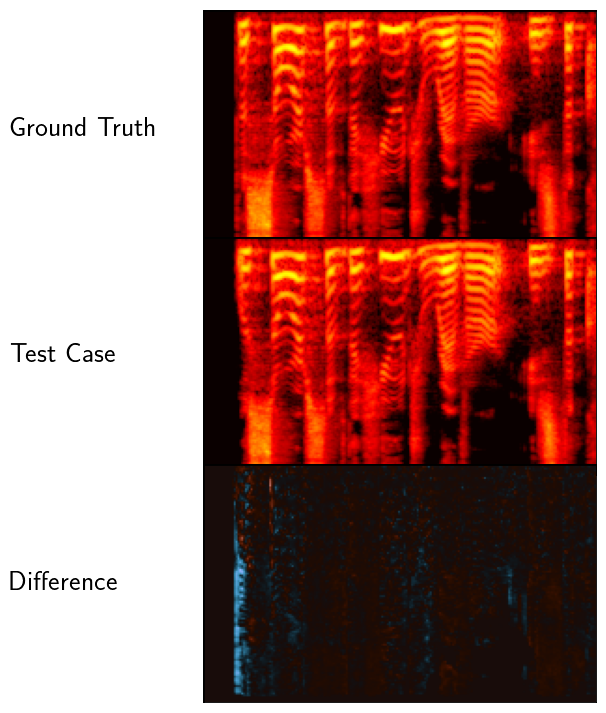

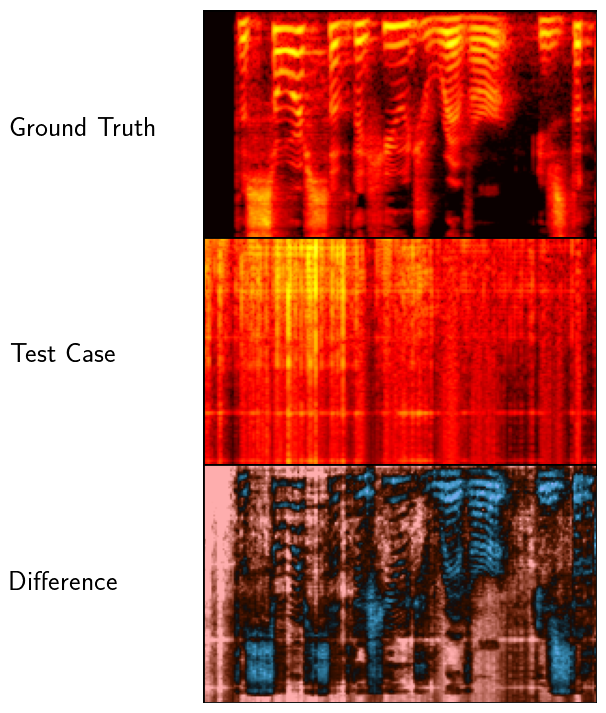

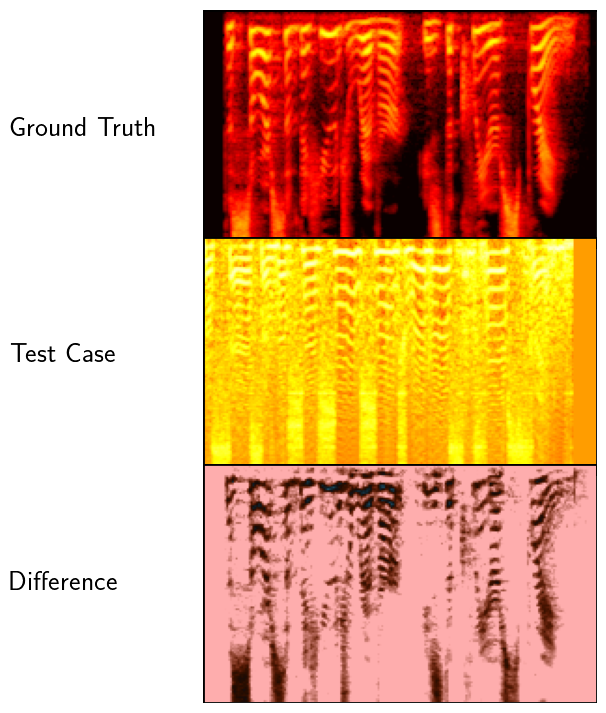

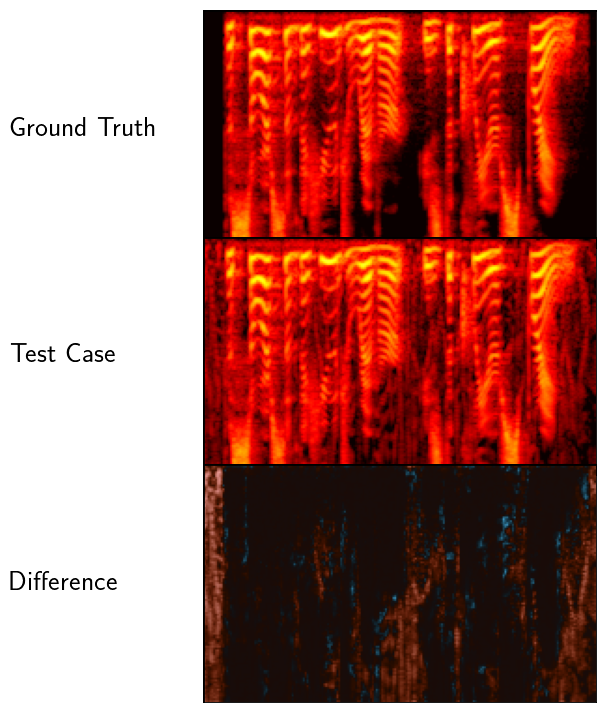

In [11]:
from matplotlib.patches import Rectangle
T = min(max(to_spectogram(g[0]).shape[1], to_spectogram(b[0]).shape[1]) for g, b in zip(gt, best))

def fit(spec, T):
    if spec.shape[1] < T:
        spec = np.pad(spec, ((0, 0), (0, T - spec.shape[1])))
    return spec[:, :T]

for m, g, b in zip(methods, gt, best):
    gsel = [e for e in g if "sentence_013" in e][0]
    bsel = [e for e in b if "sentence_013" in e][0]

    A_cut = fit(to_spectogram(gsel), T)
    B_cut = fit(to_spectogram(bsel), T)
    abs_diff = B_cut-A_cut

    fig, axes = plt.subplots(3, 2, figsize=(8, 9), gridspec_kw={"width_ratios": [1, 3], "hspace": -0.05, "wspace": 0.02})
    for i, (img, title) in enumerate(zip(
        [A_cut, B_cut, abs_diff],
        ["Ground Truth", "Test Case", "Difference"],
    )):

        if i > 1:
            norm = TwoSlopeNorm(vmin=-40, vcenter=0, vmax=40)
            axes[i, 1].imshow(img, cmap="berlin", norm=norm)
        else:
            axes[i, 1].imshow(img, cmap="hot", vmin=-60, vmax=40)
        axes[i, 1].axis("off")
        h, w = img.shape[:2]

        axes[i, 1].set_xlim(0, w)
        axes[i, 1].set_ylim(h, 0)
        rect = Rectangle((0, 0), w, h, linewidth=2, edgecolor='black', facecolor='none')
        axes[i, 1].add_patch(rect)

        axes[i, 0].axis("off")
        axes[i, 0].text(0.0, 0.5, title, fontsize=20, va="center")
    plt.savefig(f"_figures/spec_example_{m}.jpg", dpi=200, bbox_inches="tight")

## Sentence level Distances

In [15]:
whisper = load_whisper_model()
emb_model = SentenceTransformer("all-MiniLM-L6-v2")

In [16]:
def char_cosine(s1, s2):
    v1 = np.array([s1.count(c) for c in set(s1 + s2)])
    v2 = np.array([s2.count(c) for c in set(s1 + s2)])
    if (n1:=np.linalg.norm(v1)) == 0 or (n2:=np.linalg.norm(v2)) == 0:
        return 0.0
    return np.dot(v1, v2) / (n1 * n2)

In [22]:
for m, j, d in zip(methods, jsons, results):
    cos_dist, emb_dist = [], []
    for file in j:
        with open(file, "r") as f:
            jd = json.load(f)

        if jd.get("text_data"):
            gtranscr = jd["text_data"]["gt_transcription"].lower().strip()
            if "asr_transcription" in jd["text_data"].keys():
                btranscr =jd["text_data"]["asr_transcription"].lower().strip()
            else:
                btranscr =jd["text_data"]["whisper_transcription"].lower().strip()
        else:
            gtranscr, btranscr = jd["gt_text"].lower().strip(), jd["transcription"].lower().strip()

        cos_dist.append(1-char_cosine(gtranscr, btranscr))
        e1, e2 = emb_model.encode(gtranscr), emb_model.encode(btranscr)
        emb_dist.append(1 - np.dot(e1, e2) / (np.linalg.norm(e1) * np.linalg.norm(e2)))
    d |= {"cos-dist": cos_dist, "emb-dist": emb_dist}
    print(f"{m} - Cos-Dist: {np.mean(cos_dist):.3f} pm {np.std(cos_dist):.3f}")
    print(f"{m} - Emb-Dist: {np.mean(emb_dist):.3f} pm {np.std(emb_dist):.3f}")

TTS - Cos-Dist: 0.047 pm 0.066
TTS - Emb-Dist: 0.439 pm 0.190
Waveform - Cos-Dist: 0.695 pm 0.269
Waveform - Emb-Dist: 0.908 pm 0.114
SMACK - Cos-Dist: 0.191 pm 0.177
SMACK - Emb-Dist: 0.806 pm 0.224
PGD - Cos-Dist: 0.157 pm 0.103
PGD - Emb-Dist: 0.870 pm 0.130


## Statistical Analysis

In [23]:
alternative = {
    "utmos": "greater",
    "spec_distances": "less",
    "cos-dist": "less",
    "emb-dist": "less",
}

In [24]:
def cohens_d_paired(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    n = min(len(a), len(b))
    diff = a[:n] - b[:n]
    return abs(np.mean(diff) / np.std(diff, ddof=1))

In [25]:
for i, m in enumerate(results[1:], 1):
    print(f"TTS vs {methods[i]}")
    for k, vals in results[0].items():
        stat, p = wilcoxon(vals[:100], m[k][:100], alternative=alternative[k])
        d = cohens_d_paired(vals[:100], m[k][:100])
        print(f"\t{k}: p={p:.3e}; Cohens-D: {d:.1f}")

TTS vs Waveform
	utmos: p=1.948e-18; Cohens-D: 20.4
	spec_distances: p=1.948e-18; Cohens-D: 3.8
	cos-dist: p=2.133e-18; Cohens-D: 2.4
	emb-dist: p=1.875e-17; Cohens-D: 2.1
TTS vs SMACK
	utmos: p=1.948e-18; Cohens-D: 31.0
	spec_distances: p=1.948e-18; Cohens-D: 10.4
	cos-dist: p=1.786e-16; Cohens-D: 0.8
	emb-dist: p=3.057e-15; Cohens-D: 1.3
TTS vs PGD
	utmos: p=4.441e-03; Cohens-D: 0.3
	spec_distances: p=1.948e-18; Cohens-D: 5.1
	cos-dist: p=1.837e-16; Cohens-D: 0.9
	emb-dist: p=2.048e-17; Cohens-D: 1.7
